<a href="https://colab.research.google.com/github/overdosedbraincells/Healthcare_Data_Analysis/blob/main/Fizyoterapi_Klinigi_Iyilesme_Verimlilik_Analizi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

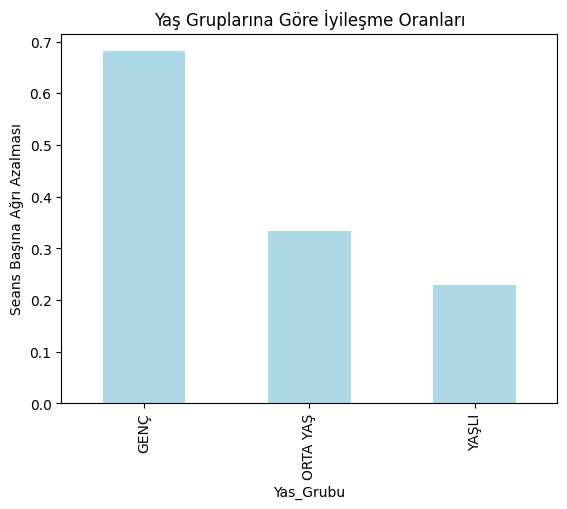

Yas_Grubu
GENÇ        0.681250
ORTA YAŞ    0.333333
YAŞLI       0.229630
Name: Iyilesme_Orani, dtype: float64


In [2]:
# Fizyoterapi Verimlilik Analizi (Öğrenme Notları)
#Bu çalışma, veri analizi yolculuğumda **apply**, **if-else fonksiyonları** ve **groupby** mantığını pekiştirmek için hazırlanmıştır.

# Hedeflerim:
# Ham veriden "İyileşme Oranı" metriğini türetmek.
# Hastaları yaş segmentlerine ayırmak.
# Farklı yaş gruplarının tedaviye yanıt verme hızlarını karşılaştırmak.

#Bu dosya gelişim sürecimin bir parçasıdır.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    'Hasta_ID': range(1, 11),
    'Yas': [22, 65, 45, 23, 70, 55, 30, 42, 68, 38],
    'Tedavi_Turu': ['Egzersiz', 'Manuel Terapi', 'Egzersiz', 'Egzersiz', 'Manuel Terapi', 'Manuel Terapi', 'Egzersiz', 'Egzersiz', 'Manuel Terapi', 'Egzersiz'],
    'Baslangic_Agri_Skoru': [8, 9, 7, 8, 10, 8, 6, 7, 9, 7],
    'Bitis_Agri_Skoru': [2, 5, 3, 1, 6, 4, 1, 3, 5, 2],
    'Seans_Sayisi': [10, 15, 12, 8, 20, 15, 6, 10, 18, 12]
}

df = pd.DataFrame(data)

df["Iyilesme_Orani"] = (df["Baslangic_Agri_Skoru"] - df["Bitis_Agri_Skoru"]) / df["Seans_Sayisi"]

def kategori(yas):
  if yas <= 40:
    return "GENÇ"
  elif yas <= 60:
    return "ORTA YAŞ"
  else:
    return "YAŞLI"

df["Yas_Grubu"] = df["Yas"].apply(kategori)

ortalama = df.groupby("Yas_Grubu")["Iyilesme_Orani"].mean()

ortalama.plot(kind="bar", color="lightblue")
plt.title("Yaş Gruplarına Göre İyileşme Oranları")
plt.ylabel("Seans Başına Ağrı Azalması")
plt.show()

print(ortalama)